# Download data (skips if data is already there

In [1]:
%run scripts/download_data.py

Skipping part1.tar.gz; already exists at /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part1.tar.gz
Skipping part2.tar.gz; already exists at /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part2.tar.gz
Skipping part3.tar.gz; already exists at /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part3.tar.gz
Done.


# Unzip files  - skip if raw data directories already exist

In [4]:
import os

# Check if the folder is empty; if so, extract the files
if os.path.isdir("data/raw/utkface/part1"):
    print("Already extracted part1, skipping.")
else:
    !tar -xzf data/raw/utkface/part1.tar.gz -C data/raw/utkface

if os.path.isdir("data/raw/utkface/part2"):
    print("Already extracted part2, skipping.")
else:
    !tar -xzf data/raw/utkface/part2.tar.gz -C data/raw/utkface

if os.path.isdir("data/raw/utkface/part3"):
    print("Already extracted part3, skipping.")
else:
    !tar -xzf data/raw/utkface/part3.tar.gz -C data/raw/utkface


Already extracted part1, skipping.
Already extracted part2, skipping.
Already extracted part3, skipping.


# Preprocess data

In [5]:
%run scripts/preprocess_data.py

Reproducibility: Random seed set to 42
RAW_DATA_DIR exists: True
RAW_DATA_DIR path: data/raw/utkface
data/raw/utkface -> 3 files
data/raw/utkface/part1 -> 10137 files
data/raw/utkface/part2 -> 10719 files
data/raw/utkface/part3 -> 3253 files
Skipped samples: 5
Train: 19283 | Valid: 2410 | Test: 2411
Sample skipped: [('61_1_20170109142408075.jpg', 'invalid_filename'), ('61_3_20170109150557335.jpg', 'invalid_filename'), ('39_1_20170116174525125.jpg', 'invalid_filename'), ('53__0_20170116184028385.jpg', 'invalid_filename'), ('.DS_Store', 'invalid_filename')]

[train] age statistics (n=19283)
  min=1  max=116  mean=33.05  median=29.0  std=20.11

[val] age statistics (n=2410)
  min=1  max=116  mean=33.11  median=29.0  std=20.22

[test] age statistics (n=2411)
  min=1  max=116  mean=32.96  median=29.0  std=20.31


# Print selected config file

In [1]:
!cat configs/linear_classification_pretrained_feature_extractor.yaml

# Config file for ResNet18 pretrained on ImageNet, used as a frozen feature extractor for linear classification. 

experiment_name: "linear_classification_pretrained_feature_extractor"
model_name: "linear"  # linear, mlp, or mlp_dropout
seed: 42
pretrained: True
freeze_backbone: True     # Whether to fine-tune the pretrained model or just use it as a feature extractor
task: "classification"   # regression or classification
metric: "mae"       # mse for regression, accuracy for classification

# Data parameters
batch_size: 32
num_workers: 4
image_size: 224

# Training parameters
epochs: 30
learning_rate: 0.001
optimizer: "Adam"
#loss_function: "CrossEntropyLoss" unsed since we set it in train.py based on task
save_best: True
weight_decay: 0.01

# MLP + Dropout
dropout: 0.2


# Train randomly initialized ResNet18

Reproducibility: Random seed set to 42
Pipeline Initialized. Loading data and model...
Using AdamW optimizer with weight decay: 0.01
Setup complete! Ready to begin training epochs.


100%|##########################################################################################################################################| 76/76 [00:33<00:00,  2.30it/s, loss=3.59]


Epoch [1/30] Train Loss: 3.7824, Train MAE: 11.4645, Train MSE: 235.9323, Train Acc@3: 0.1882, Train Acc@5: 0.3109 | Val Loss: 3.5915, Val MAE: 9.7861, Val MSE: 173.1953, Val Acc@3: 0.2228, Val Acc@5: 0.3618, Val MAE: 9.7861


100%|##########################################################################################################################################| 76/76 [00:34<00:00,  2.17it/s, loss=3.53]


Epoch [2/30] Train Loss: 3.4321, Train MAE: 9.4585, Train MSE: 166.6093, Train Acc@3: 0.2497, Train Acc@5: 0.3828 | Val Loss: 3.5333, Val MAE: 8.7969, Val MSE: 149.0298, Val Acc@3: 0.2801, Val Acc@5: 0.4187, Val MAE: 8.7969


...

Epoch [28/30] Train Loss: 2.8251, Train MAE: 7.5506, Train MSE: 118.1781, Train Acc@3: 0.3410, Train Acc@5: 0.4892 | Val Loss: 3.8077, Val MAE: 7.8911, Val MSE: 131.8611, Val Acc@3: 0.3336, Val Acc@5: 0.4759, Val MAE: 7.8911


100%|##########################################################################################################################################| 76/76 [00:33<00:00,  2.26it/s, loss=3.77]


Epoch [29/30] Train Loss: 2.8156, Train MAE: 7.5341, Train MSE: 115.4749, Train Acc@3: 0.3403, Train Acc@5: 0.4876 | Val Loss: 3.7749, Val MAE: 7.9405, Val MSE: 132.5834, Val Acc@3: 0.3295, Val Acc@5: 0.4722, Val MAE: 7.9405


100%|##########################################################################################################################################| 76/76 [00:33<00:00,  2.26it/s, loss=3.83]


Epoch [30/30] Train Loss: 2.8160, Train MAE: 7.5658, Train MSE: 117.7392, Train Acc@3: 0.3381, Train Acc@5: 0.4882 | Val Loss: 3.8279, Val MAE: 7.9021, Val MSE: 138.8871, Val Acc@3: 0.3531, Val Acc@5: 0.4917, Val MAE: 7.9021
Saving Best Val MAE: 7.7311 at Epoch 30
Saved model with MAE = 7.7311
Saved training stats history to /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/outputs/stats_history_linear_classification_pretrained_feature_extractor.npy
Training completely finished! Best Val Loss: 3.7525, Best Val MAE: 7.7311


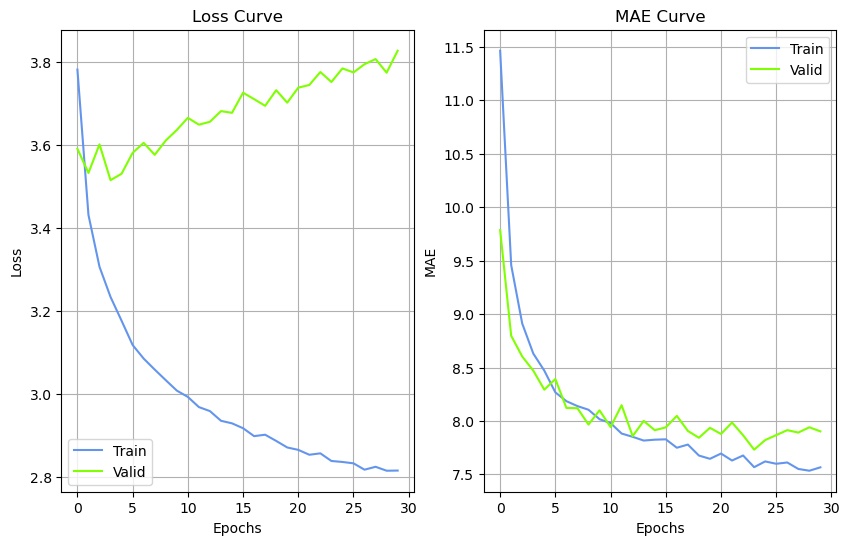

In [2]:
%run scripts/train.py --config configs/linear_classification_pretrained_feature_extractor.yaml

# Evaluate randomly initialized ResNet18

In [3]:
%run scripts/evaluate.py --config configs/linear_classification_pretrained_feature_extractor.yaml

Reproducibility: Random seed set to 42
Configuration loaded. Loading data and model...
Loading model from checkpoint: /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/outputs/checkpoint_linear_classification_pretrained_feature_extractor.pth


100%|###########################################################################################################################################| 76/76 [00:31<00:00,  2.39it/s, loss=3.7]


Evaluation Metrics — linear_classification_pretrained_feature_extractor
+--------+----------+
| Metric |    Value |
+--------+----------+
| MAE    |   7.7958 |
| MSE    | 130.6314 |
| Acc@3  |   0.3339 |
| Acc@5  |   0.4749 |
+--------+----------+


# Plot validation curves

Epochs 0-10: Best Val MAE = 7.9661
Epochs 0-20: Best Val MAE = 7.8425
Epochs 0-30: Best Val MAE = 7.7311


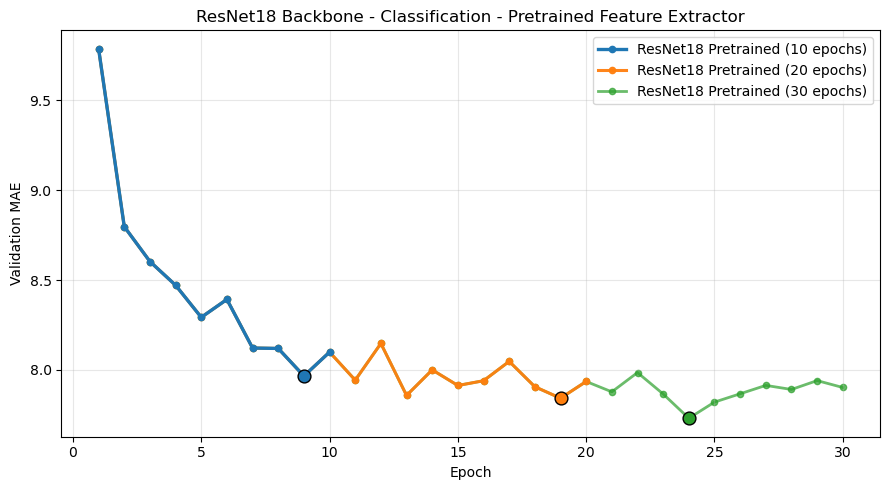

In [4]:
import numpy
from src.utils.plots import plot_validation_curves
# Load the file into a variable
data = numpy.load('outputs/stats_history_linear_classification_pretrained_feature_extractor.npy', allow_pickle=True).item()

plot_validation_curves(data['eval'], title='ResNet18 Backbone - Classification - Pretrained Feature Extractor', label='ResNet18 Pretrained')